# Diabetes Project: Who develops diabetes within five years?

**Khaldoun & Dominic** · Pima Indians Diabetes Database · logistic regression, one pass through the workflow

> **In one sentence:** Glucose is the strongest single sign, and a logistic regression with a decision threshold chosen for our metric finds **50 of 54** future diabetes cases on unseen patients (F2 = 0.81), four more than a simple glucose rule, at the price of more false alarms.

| | Section | Time |
| :-- | :-- | :-- |
| 1 | Goal: which mistake matters, and our hypotheses | 1 min |
| 2 | Data: hidden missing values and the split | 40 s |
| 3 | Hypothesis tests and verdicts | 1 min |
| 4 | Models: baseline, logistic regression, the threshold | 1 min |
| 5 | Test set: final table and confusion matrix | 1 min |
| 6 | Conclusion and limits | 20 s |

The appendix holds the questions we expect, with short answers. The full working notebook with every step is `01_diabetes_project copy.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, fbeta_score, precision_score, recall_score

P_MIN = 0.5           # precision floor, fixed in section 1 before looking at the data
ALPHA = 0.05 / 3      # Bonferroni: three tests
ZERO_MEANS_MISSING = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]


def classification_scores(y_true, y_pred):
    """F2 (main metric), precision, recall, accuracy, and whether the precision floor holds."""
    precision = precision_score(y_true, y_pred, zero_division=0)
    return {
        "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision,
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "meets P_min": precision >= P_MIN,
    }


def best_cutoff(y_true, scores):
    """The cut-off with the highest F2 among those whose precision is at least P_MIN (training data only)."""
    table = pd.DataFrame([
        {"cutoff": c, **classification_scores(y_true, (scores >= c).astype(int))} for c in np.unique(scores)
    ])
    allowed = table[table["meets P_min"]]
    return allowed.loc[allowed["F2"].idxmax(), "cutoff"], table

## 1 · Goal: which mistake matters?

**The data are a prognosis, not a diagnosis.** The paper behind the data set selected one examination per woman with a *non-diabetic* glucose test. `Outcome = 1` means diabetes was diagnosed **1 to 5 years later**. So the model answers: *"Who will develop diabetes in the next five years?"*

| Mistake | What it means for a patient | Cost |
| :-- | :-- | :-- |
| **False negative** (missed case) | no prevention: no lifestyle advice, no close monitoring | high |
| **False positive** (false alarm) | an unnecessary check-up and some worry | low |

**Our metric, fixed before we looked at the data:**
- **F2** weights a missed case **4 ×** as heavily as a false alarm (F-beta weights FN β² times, β = 2). The 4 is our assumption, not a fact.
- **Precision floor `P_min = 0.5`:** at most one unnecessary check-up per case found. Without it, F2 rewards "everyone has diabetes" (see the table in section 5).
- Accuracy only as a warning light.

**Research question:** Which characteristics measured at the examination indicate that a woman will develop diabetes within five years?

| | Hypothesis (written before looking at the data) | Column | Test plan |
| :-- | :-- | :-- | :-- |
| H1 | The higher the BMI, the more likely diabetes. | `BMI` | Mann-Whitney U, one-tailed |
| H2 | The more pregnancies, the more likely diabetes (bands 0 / 1–3 / 4–6 / 7+). | `Pregnancies` | χ² test on the bands |
| H3 | Insulin differs between the groups; direction open (resistance → higher, failing pancreas → lower). | `Insulin` | Mann-Whitney U, two-tailed |

Three tests, so **α = 0.05 / 3 ≈ 0.0167** (Bonferroni).

## 2 · Data: hidden missing values and the split

- `df.info()` reports no missing values, but **zeros hide them**: a glucose, blood pressure, skin fold, insulin or BMI of 0 is biologically impossible. `Pregnancies = 0` is real.
- **Rule fixed in advance:** 0 → NaN in exactly these five columns. It learns nothing from the data, so it may run before the split.
- **Split:** 80 / 20, stratified on `Outcome`, `random_state=42`. All exploration on `df_train` only.
- **Filling:** NaN → **training median** (most columns are skewed). The test set is filled with the *same training* medians, never with its own.

In [2]:
df = pd.read_csv("data/diabetes.csv")
zeros_in_raw_data = (df[ZERO_MEANS_MISSING] == 0).sum()
df[ZERO_MEANS_MISSING] = df[ZERO_MEANS_MISSING].replace(0, np.nan)

df_train, df_test = train_test_split(df, test_size=0.2, stratify=df["Outcome"], random_state=42)
TRAIN_MEDIANS = df_train[ZERO_MEANS_MISSING].median()


def apply_cleaning(data):
    """The same step for train and test: fill the NaNs with the training medians."""
    cleaned = data.copy()
    cleaned[ZERO_MEANS_MISSING] = cleaned[ZERO_MEANS_MISSING].fillna(TRAIN_MEDIANS)
    return cleaned


df_train_clean, df_test_clean = apply_cleaning(df_train), apply_cleaning(df_test)
FEATURES = list(df.columns.drop("Outcome"))
X_train, y_train = df_train_clean[FEATURES], df_train_clean["Outcome"]
X_test, y_test = df_test_clean[FEATURES], df_test_clean["Outcome"]

print(f"{len(df)} patients, {df['Outcome'].mean():.1%} develop diabetes | train {len(df_train)}, test {len(df_test)}")
missing = df_train[ZERO_MEANS_MISSING].isna()
pd.DataFrame({
    "zeros in raw data": zeros_in_raw_data,
    "missing in train, Outcome 0": missing[df_train["Outcome"] == 0].mean().map("{:.0%}".format),
    "missing in train, Outcome 1": missing[df_train["Outcome"] == 1].mean().map("{:.0%}".format),
    "filled with train median": TRAIN_MEDIANS,
})

768 patients, 34.9% develop diabetes | train 614, test 154


,zeros in raw data,"missing in train, Outcome 0","missing in train, Outcome 1",filled with train median
Glucose,5,0%,1%,117.0
BloodPressure,35,3%,5%,72.0
SkinThickness,227,27%,31%,29.0
Insulin,374,46%,49%,125.0
BMI,11,2%,1%,32.4


**What to say:**
- **Insulin is missing for almost every second woman**, SkinThickness for almost a third. Whenever SkinThickness is missing, Insulin is missing too: some women simply did not get both measurements.
- **It is missing about equally often in both groups** (46 % vs. 49 % for insulin), so the gaps hardly depend on the outcome. Tests on the measured rows do not look at a strongly selected subgroup.
- **Check against the paper:** the highest glucose in the training data is 199, just below the diabetic limit of 200. The file matches the paper's selection rule.

## 3 · Hypothesis tests and verdicts

Tests run on the training set **before filling** (NaN dropped per test), because filling half the insulin column with one value would blur the difference. Shapiro rejected normality for BMI and Insulin, so we use the rank-based **Mann-Whitney U**. It tests whether one group *tends to have higher values*, not whether the means differ.

**Effect size, in plain words:** rank-biserial r → (r + 1) / 2 = the share of random pairs (one woman with, one without diabetes) in which the woman with diabetes has the higher value. 50 % would mean no relationship.

In [3]:
def mann_whitney(col, alternative):
    with_diabetes = df_train.loc[df_train["Outcome"] == 1, col].dropna()
    without_diabetes = df_train.loc[df_train["Outcome"] == 0, col].dropna()
    u, p = stats.mannwhitneyu(with_diabetes, without_diabetes, alternative=alternative)
    r = 2 * u / (len(with_diabetes) * len(without_diabetes)) - 1
    return {"n": len(with_diabetes) + len(without_diabetes),
            "result": f"median {with_diabetes.median():.1f} vs. {without_diabetes.median():.1f}",
            "p": f"{p:.1e}", "effect size": f"r = {r:.2f}, higher in {(r + 1) / 2:.0%} of pairs"}


pregnancy_band = pd.cut(df_train["Pregnancies"], bins=[-0.5, 0.5, 3.5, 6.5, np.inf], labels=["0", "1–3", "4–6", "7+"])
observed = pd.crosstab(pregnancy_band, df_train["Outcome"])
chi2, p_h2, dof, expected = stats.chi2_contingency(observed)
share_per_band = observed[1] / observed.sum(axis=1)

pd.DataFrame({
    "H1 BMI": {"test": "Mann-Whitney U, one-tailed", **mann_whitney("BMI", "greater"),
               "verdict": "supported"},
    "H2 Pregnancies": {"test": "χ², 4 bands × Outcome", "n": len(df_train),
                       "result": "share with diabetes " + " / ".join(f"{s:.2f}" for s in share_per_band),
                       "p": f"{p_h2:.1e}", "effect size": f"Cramér's V = {np.sqrt(chi2 / len(df_train)):.2f}",
                       "verdict": "cannot tell yet"},
    "H3 Insulin": {"test": "Mann-Whitney U, two-tailed", **mann_whitney("Insulin", "two-sided"),
                   "verdict": "supported, higher"},
}).T

,test,n,result,p,effect size,verdict
H1 BMI,"Mann-Whitney U, one-tailed",605,median 34.3 vs. 30.1,1.6e-15,"r = 0.39, higher in 69% of pairs",supported
H2 Pregnancies,"χ², 4 bands × Outcome",614,share with diabetes 0.36 / 0.25 / 0.32 / 0.56,1.4e-08,Cramér's V = 0.25,cannot tell yet
H3 Insulin,"Mann-Whitney U, two-tailed",324,median 168.0 vs. 100.0,6.5e-14,"r = 0.51, higher in 75% of pairs","supported, higher"


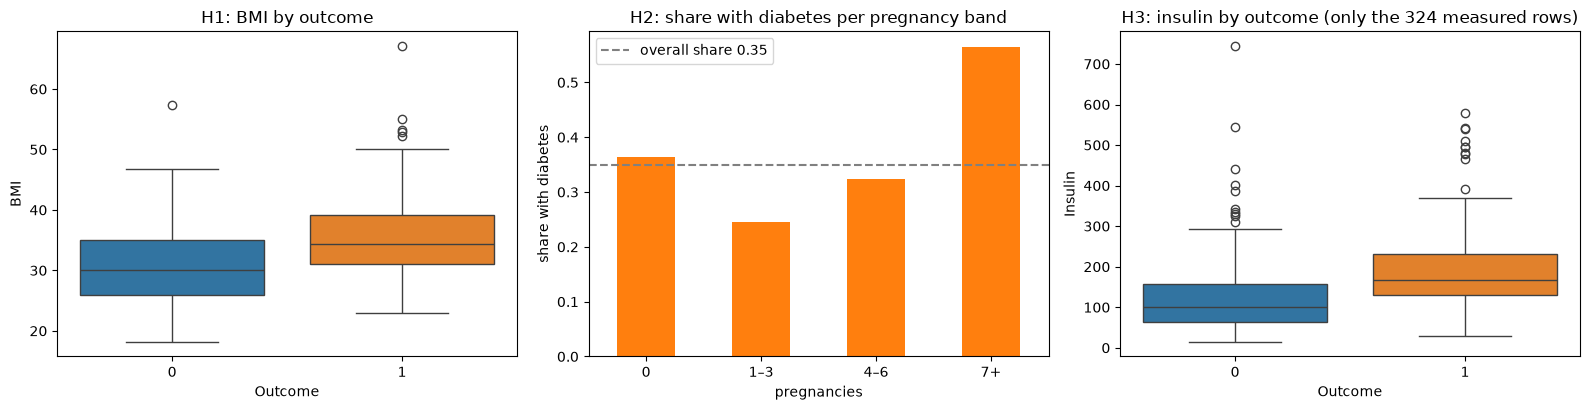

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sns.boxplot(data=df_train, x="Outcome", y="BMI", hue="Outcome", legend=False, ax=axes[0])
axes[0].set_title("H1: BMI by outcome")
share_per_band.plot(kind="bar", color="tab:orange", rot=0, ax=axes[1])
axes[1].axhline(y_train.mean(), color="grey", linestyle="--", label=f"overall share {y_train.mean():.2f}")
axes[1].set(title="H2: share with diabetes per pregnancy band", xlabel="pregnancies", ylabel="share with diabetes")
axes[1].legend()
sns.boxplot(data=df_train, x="Outcome", y="Insulin", hue="Outcome", legend=False, ax=axes[2])
axes[2].set_title(f"H3: insulin by outcome (only the {df_train['Insulin'].notna().sum()} measured rows)")
plt.tight_layout()
plt.show()

**What to say:**
- **H1 supported:** p far below 0.0167; in 69 % of pairs the woman who develops diabetes has the higher BMI. A medium effect.
- **H2 cannot tell yet,** although p is tiny: the share depends on the band, but it does **not rise steadily** (0 pregnancies: 0.36, 1–3: 0.25). The jump comes from 7+, which is also the oldest group (median age 42); Pregnancies and Age correlate with ρ = 0.61. χ² cannot separate the two, and we had fixed beforehand that "supported" needs rising shares.
- **H3 supported, direction higher:** the largest effect (75 % of pairs). This fits insulin resistance, the early stage before diabetes. Limit: only 324 of 614 rows have a value.

## 4 · Models: baseline, logistic regression, the threshold

| Model | What it does |
| :-- | :-- |
| Random baseline | `DummyClassifier(strategy="stratified")`: guesses in the class proportions |
| Rule baseline | "Glucose ≥ cut-off means diabetes"; cut-off chosen on train with **our rule: highest F2 with precision ≥ 0.5** |
| Logistic regression A / B | `StandardScaler` (fitted on train only) + `LogisticRegression`; A = all 8 features, B = without Insulin and SkinThickness |
| … `class_weight="balanced"` | each diabetes case counts about 1.9 × during training |
| … own threshold | instead of p ≥ 0.5: the threshold with the highest F2 at precision ≥ 0.5, chosen on train |

In [5]:
dummy = DummyClassifier(strategy="stratified", random_state=42).fit(X_train, y_train)
GLUCOSE_CUTOFF, _ = best_cutoff(y_train, X_train["Glucose"])
FEATURES_B = [col for col in FEATURES if col not in ["Insulin", "SkinThickness"]]


def fit_logreg(features, class_weight=None):
    scaler = StandardScaler().fit(X_train[features])  # learned from the training data only
    model = LogisticRegression(class_weight=class_weight).fit(scaler.transform(X_train[features]), y_train)
    return model, lambda X: model.predict_proba(scaler.transform(X[features]))[:, 1]


logreg, proba_logreg = fit_logreg(FEATURES)
logreg_b, proba_logreg_b = fit_logreg(FEATURES_B)
logreg_balanced, proba_logreg_balanced = fit_logreg(FEATURES, "balanced")
logreg_balanced_b, proba_logreg_balanced_b = fit_logreg(FEATURES_B, "balanced")

probabilities = {"logreg A": proba_logreg, "logreg B": proba_logreg_b,
                 "logreg A balanced": proba_logreg_balanced, "logreg B balanced": proba_logreg_balanced_b}
THRESHOLDS = {name: best_cutoff(y_train, proba(X_train))[0] for name, proba in probabilities.items()}

models = {
    "random baseline": lambda X: dummy.predict(X),
    "reference: everyone has diabetes": lambda X: np.ones(len(X), dtype=int),
    f"rule: Glucose ≥ {GLUCOSE_CUTOFF:.0f}": lambda X: (X["Glucose"] >= GLUCOSE_CUTOFF).astype(int),
}
for name, proba in probabilities.items():
    models[f"{name}, threshold 0.5"] = lambda X, proba=proba: (proba(X) >= 0.5).astype(int)
    models[f"{name}, threshold {THRESHOLDS[name]:.2f}"] = (
        lambda X, proba=proba, t=THRESHOLDS[name]: (proba(X) >= t).astype(int))
CHOSEN_MODEL = f"logreg B balanced, threshold {THRESHOLDS['logreg B balanced']:.2f}"
print(f"Glucose cut-off: {GLUCOSE_CUTOFF:.0f} | thresholds:", {k: round(v, 2) for k, v in THRESHOLDS.items()})

Glucose cut-off: 112 | thresholds: {'logreg A': np.float64(0.19), 'logreg B': np.float64(0.16), 'logreg A balanced': np.float64(0.27), 'logreg B balanced': np.float64(0.26)}


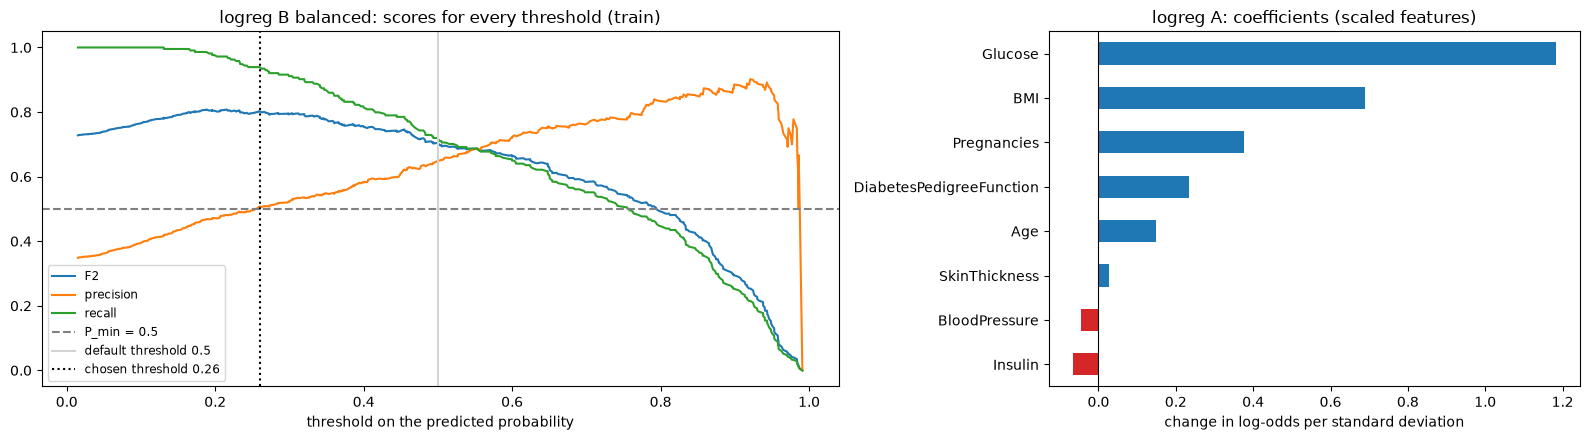

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), gridspec_kw={"width_ratios": [3, 2]})

_, threshold_table = best_cutoff(y_train, proba_logreg_balanced_b(X_train))
for score in ["F2", "precision", "recall"]:
    axes[0].plot(threshold_table["cutoff"], threshold_table[score], label=score)
axes[0].axhline(P_MIN, color="grey", linestyle="--", label="P_min = 0.5")
axes[0].axvline(0.5, color="lightgrey", label="default threshold 0.5")
axes[0].axvline(THRESHOLDS["logreg B balanced"], color="black", linestyle=":",
                label=f"chosen threshold {THRESHOLDS['logreg B balanced']:.2f}")
axes[0].set(title="logreg B balanced: scores for every threshold (train)", xlabel="threshold on the predicted probability")
axes[0].legend(loc="lower left", fontsize="small")

coefficients = pd.Series(logreg.coef_[0], index=FEATURES).sort_values()
coefficients.plot(kind="barh", color=["tab:red" if c < 0 else "tab:blue" for c in coefficients], ax=axes[1])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set(title="logreg A: coefficients (scaled features)", xlabel="change in log-odds per standard deviation")
plt.tight_layout()
plt.show()

**What to say:**
- **The threshold is the decisive lever.** With the default 0.5 the model is cautious: high precision, but it finds only about 60 % of the cases, and its F2 (0.62) is **below the glucose rule** (0.73). Moving the threshold down to where precision just reaches 0.5 lifts F2 to 0.80 on the training set.
- **`balanced` and the threshold do much the same thing:** both move the line between "diabetes" and "no diabetes". With its own threshold, the model without weights is just as good (0.80); the weights mainly shift where the threshold lands (0.26 instead of 0.16).
- **Coefficients:** Glucose dominates (odds × 3.3 per standard deviation), then BMI and Pregnancies. **Insulin ≈ 0**, although it had the largest effect in H3: the test looked at insulin alone, the model asks what it adds *on top of glucose* (ρ = 0.67), and half of its values are the filled median. That is also why **variant B** without Insulin and SkinThickness loses nothing.
- **Our choice, made on the training data:** logreg B balanced with its own threshold: highest training F2, fewest features, and the class weights the task asks for.

## 5 · Test set: final table and confusion matrix

Only now do we touch `df_test` (cleaned with the training medians, scaled with the training scalers, thresholds from the training data). We report **every** model, but we do not switch models because of these numbers.

In [7]:
rows = {}
for name, predict in models.items():
    train, test = classification_scores(y_train, predict(X_train)), classification_scores(y_test, predict(X_test))
    rows[("► " if name == CHOSEN_MODEL else "") + name] = {
        "F2 train": train["F2"], "F2 test": test["F2"],
        "precision test": test["precision"], "recall test": test["recall"],
        "accuracy test": test["accuracy"], "meets P_min (test)": test["meets P_min"],
    }
pd.DataFrame.from_dict(rows, orient="index").sort_values("F2 train", ascending=False).round(3)

,F2 train,F2 test,precision test,recall test,accuracy test,meets P_min (test)
"► logreg B balanced, threshold 0.26",0.803,0.806,0.532,0.926,0.688,True
"logreg B, threshold 0.16",0.801,0.804,0.526,0.926,0.682,True
"logreg A balanced, threshold 0.27",0.799,0.806,0.532,0.926,0.688,True
"logreg A, threshold 0.19",0.795,0.784,0.533,0.889,0.688,True
rule: Glucose ≥ 112,0.731,0.764,0.541,0.852,0.695,True
reference: everyone has diabetes,0.728,0.730,0.351,1.000,0.351,False
"logreg B balanced, threshold 0.5",0.701,0.681,0.603,0.704,0.734,True
"logreg A balanced, threshold 0.5",0.695,0.681,0.603,0.704,0.734,True
"logreg A, threshold 0.5",0.622,0.517,0.600,0.500,0.708,True
"logreg B, threshold 0.5",0.617,0.500,0.591,0.481,0.701,True


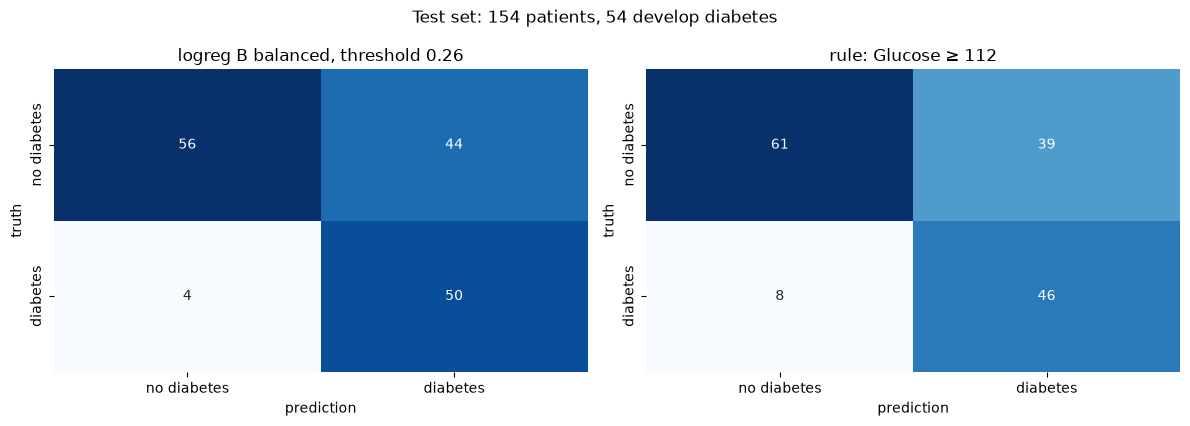

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, name in zip(axes, [CHOSEN_MODEL, f"rule: Glucose ≥ {GLUCOSE_CUTOFF:.0f}"]):
    sns.heatmap(confusion_matrix(y_test, models[name](X_test)), annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["no diabetes", "diabetes"], yticklabels=["no diabetes", "diabetes"])
    ax.set(title=name, xlabel="prediction", ylabel="truth")
plt.suptitle(f"Test set: {len(y_test)} patients, {y_test.sum()} develop diabetes")
plt.tight_layout()
plt.show()

**What to say:**
- **The chosen model holds on new patients:** F2 0.81 on test vs. 0.80 on train, so there is no sign of overfitting. Precision 0.53 stays above the floor, recall 0.93.
- **What it gets right:** it finds **50 of 54** future cases and misses only **4**. The glucose rule misses 8.
- **Where it still makes mistakes:** **44 false alarms**: 44 of 100 women who stay healthy would get an unnecessary check-up. By our own cost assumption (1 missed case ≈ 4 false alarms), trading 4 fewer missed cases for 5 more false alarms is worth it.
- **Beats both baselines:** random (F2 0.38) by far, the glucose rule (0.76) by about **four cases**: real, but small. With 54 positive cases, one case moves recall by 0.02.
- **Accuracy would have chosen the wrong model:** the models with threshold 0.5 have higher accuracy (0.70 to 0.73), but they miss 30 to 52 % of the cases.

## 6 · Conclusion and limits

**Answer to the research question:** **Glucose** is by far the strongest sign; **BMI** (H1) and **insulin** (H3, higher) differ clearly between the groups, but insulin adds nothing on top of glucose. **Pregnancies** (H2) cannot be separated from age with our test. A logistic regression with a threshold chosen for F2 finds 93 % of future cases at precision 0.53.

**Limits:**
- Small test set (54 positive cases): differences of a few hundredths are noise.
- Thresholds were chosen on the training data they were scored on; cross-validation (week 3) would be more honest.
- β = 2 and `P_min = 0.5` are cost assumptions: other costs → another "best" model.
- One population (Pima women, 21+): results do not transfer automatically.

---
## Appendix: questions we expect

**Why F2 and not accuracy or F1?** The data describe a prognosis, and a missed case costs a chance for prevention, a false alarm only a check-up. F1 weights both equally, accuracy is dominated by the 65 % healthy women. F2 weights a missed case 4 ×.

**Why the precision floor?** "Everyone has diabetes" reaches F2 = 0.73 on train, as good as the glucose rule (formula 5p / (4p + 1) with p = 0.35). Its precision is 0.35, so the floor of 0.5 rules it out.

**Isn't replacing zeros before the split leakage?** No: the column list and the rule were fixed beforehand and learn nothing from the data. Leakage would be *filling* with a median computed from all rows; we fill with training medians only.

**Why the median, and why not drop rows?** Most columns are skewed, the median is not pulled by the long tail. Dropping rows would leave 322 of 614 training rows and lose half the patients. Dropping the two worst columns is our variant B, and it changes nothing.

**Why Mann-Whitney and not a t-test?** Shapiro rejected normality in both groups for BMI and Insulin (insulin skew 2.0). Mann-Whitney compares ranks, so outliers cannot dominate. For BMI, Welch would also be defensible because of the large sample, but we stuck to the rule we wrote down before.

**H2 has p = 1e-8. Why "cannot tell yet"?** The test only says the share differs between bands, not that it rises. It does not rise steadily (0 pregnancies > 1–3), and the 7+ band is the oldest group. We fixed before the test that "supported" needs rising shares.

**Insulin was strongest in the test but has a coefficient of 0. Contradiction?** No. The test looks at insulin alone; the model asks what insulin adds when glucose is already known (ρ = 0.67). Plus, half of its values are the filled median.

**Isn't a threshold chosen on the training data optimistic?** Yes, slightly. But it was not chosen on the test set, and the test scores (F2 0.81) match the training scores (0.80). Cross-validation would be the next step.

**Do you need both `balanced` and the threshold?** The threshold alone already gets there (F2 0.80); the weights mainly move where the threshold lands. We kept them because the task asks for them and they cost nothing.

**Is Glucose a leak? Isn't diabetes defined by glucose?** Not here: the glucose value is from an examination with a *non-diabetic* result, and the diagnosis came 1 to 5 years later. It is known at prediction time.

**How does this compare with the paper?** The ADAP network reached sensitivity = specificity = 0.76. We work at another point of the trade-off (sensitivity 0.93, specificity 0.56), on a different split, so the numbers are not directly comparable.